<a href="https://colab.research.google.com/github/hamzao18/Credit-Card/blob/main/Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Read Data & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
df1=pd.read_csv('/content/application_record.csv')
df2=pd.read_csv('/content/credit_record.csv')
df = pd.merge(df1, df2, on='ID', how='inner')
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-9,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-10,2
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-11,1
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-12,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  object 
 2   FLAG_OWN_CAR         777715 non-null  object 
 3   FLAG_OWN_REALTY      777715 non-null  object 
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  object 
 7   NAME_EDUCATION_TYPE  777715 non-null  object 
 8   NAME_FAMILY_STATUS   777715 non-null  object 
 9   NAME_HOUSING_TYPE    777715 non-null  object 
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL       

###Rename Coloums

In [ ]:
df=df.rename(columns={"FLAG_OWN_CAR":"Car",
                      "FLAG_OWN_REALTY":"Realty",
                      "CNT_CHILDREN" : 'Children',
                      "AMT_INCOME_TOTAL":"Salary",
                      "NAME_INCOME_TYPE":"Income type",
                      "NAME_EDUCATION_TYPE":"Education",
                      "NAME_FAMILY_STATUS":"Family_type",
                      "NAME_HOUSING_TYPE":"House_type",
                      "FLAG_MOBIL":"Mobile",
                      "FLAG_EMAIL":"EMail",
                      "OCCUPATION_TYPE":"Work_type",
                      "CNT_FAM_MEMBERS":"Family_member",
                      "CODE_GENDER":"Gender"})
df

,ID,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-9,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-10,2
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-11,1
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-12,0


###Handel Null Values

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Car,0
Realty,0
Children,0
Salary,0
Income type,0
Education,0
Family_type,0
House_type,0


In [ ]:
df['Work_type'].fillna(df['Work_type'].mode()[0], inplace=True)

<ipython-input-6-d15cf57a53d5>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Work_type'].fillna(df['Work_type'].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Car,0
Realty,0
Children,0
Salary,0
Income type,0
Education,0
Family_type,0
House_type,0


In [ ]:
df['Work_type']

,Work_type
0,Laborers
1,Laborers
2,Laborers
3,Laborers
4,Laborers
...,...
777710,Laborers
777711,Laborers
777712,Laborers
777713,Laborers


In [ ]:
df

,ID,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Laborers,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Laborers,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Laborers,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Laborers,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Laborers,2.0,-4,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-9,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-10,2
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-11,1
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,Laborers,1.0,-12,0


###Label Encoding

In [ ]:
le=LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Car'] = le.fit_transform(df['Car'])
df['Realty'] = le.fit_transform(df['Realty'])
df["STATUS"] = le.fit_transform(df["STATUS"])
df['Work_type'] = le.fit_transform(df['Work_type'])
df

,ID,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,8,2.0,0,6
1,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,8,2.0,-1,6
2,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,8,2.0,-2,6
3,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,8,2.0,-3,6
4,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,8,2.0,-4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,1,0,1,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,8,1.0,-9,0
777711,5150337,1,0,1,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,8,1.0,-10,2
777712,5150337,1,0,1,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,8,1.0,-11,1
777713,5150337,1,0,1,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,-9188,-1193,1,0,0,0,8,1.0,-12,0


###Convert Coloums to float

In [ ]:
columns_to_convert = ['Income type', 'Education', 'Family_type', 'House_type']
for column in columns_to_convert:
    df[column] = le.fit_transform(df[column])

In [ ]:
df.drop(columns={"ID"}, inplace=True)
df

,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,8,2.0,0,6
1,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,8,2.0,-1,6
2,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,8,2.0,-2,6
3,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,8,2.0,-3,6
4,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,8,2.0,-4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,1,0,1,0,112500.0,4,4,3,4,-9188,-1193,1,0,0,0,8,1.0,-9,0
777711,1,0,1,0,112500.0,4,4,3,4,-9188,-1193,1,0,0,0,8,1.0,-10,2
777712,1,0,1,0,112500.0,4,4,3,4,-9188,-1193,1,0,0,0,8,1.0,-11,1
777713,1,0,1,0,112500.0,4,4,3,4,-9188,-1193,1,0,0,0,8,1.0,-12,0


###Absolut columns

In [ ]:
df["DAYS_BIRTH"] = df["DAYS_BIRTH"].abs()
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].abs()

df

,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,8,2.0,0,6
1,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,8,2.0,-1,6
2,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,8,2.0,-2,6
3,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,8,2.0,-3,6
4,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,8,2.0,-4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,1,0,1,0,112500.0,4,4,3,4,9188,1193,1,0,0,0,8,1.0,-9,0
777711,1,0,1,0,112500.0,4,4,3,4,9188,1193,1,0,0,0,8,1.0,-10,2
777712,1,0,1,0,112500.0,4,4,3,4,9188,1193,1,0,0,0,8,1.0,-11,1
777713,1,0,1,0,112500.0,4,4,3,4,9188,1193,1,0,0,0,8,1.0,-12,0


###Scaling

In [ ]:
scaler = MinMaxScaler()
df['Salary'] = scaler.fit_transform(df[['Salary']])
df["DAYS_EMPLOYED"] = scaler.fit_transform(df[["DAYS_EMPLOYED"]])
df['DAYS_BIRTH'] = scaler.fit_transform(df[['DAYS_BIRTH']])

In [ ]:
unique_types = df['Education'].unique()   # TO Know Unique types
unique_types

array([1, 4, 2, 3, 0])

In [ ]:
df

,Gender,Car,Realty,Children,Salary,Income type,Education,Family_type,House_type,DAYS_BIRTH,DAYS_EMPLOYED,Mobile,FLAG_WORK_PHONE,FLAG_PHONE,EMail,Work_type,Family_member,MONTHS_BALANCE,STATUS
0,1,1,1,0,0.258721,4,1,0,4,0.255676,0.01239,1,1,0,0,8,2.0,0,6
1,1,1,1,0,0.258721,4,1,0,4,0.255676,0.01239,1,1,0,0,8,2.0,-1,6
2,1,1,1,0,0.258721,4,1,0,4,0.255676,0.01239,1,1,0,0,8,2.0,-2,6
3,1,1,1,0,0.258721,4,1,0,4,0.255676,0.01239,1,1,0,0,8,2.0,-3,6
4,1,1,1,0,0.258721,4,1,0,4,0.255676,0.01239,1,1,0,0,8,2.0,-4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,1,0,1,0,0.055233,4,4,3,4,0.096190,0.00322,1,0,0,0,8,1.0,-9,0
777711,1,0,1,0,0.055233,4,4,3,4,0.096190,0.00322,1,0,0,0,8,1.0,-10,2
777712,1,0,1,0,0.055233,4,4,3,4,0.096190,0.00322,1,0,0,0,8,1.0,-11,1
777713,1,0,1,0,0.055233,4,4,3,4,0.096190,0.00322,1,0,0,0,8,1.0,-12,0


#Visualization

###Distribution

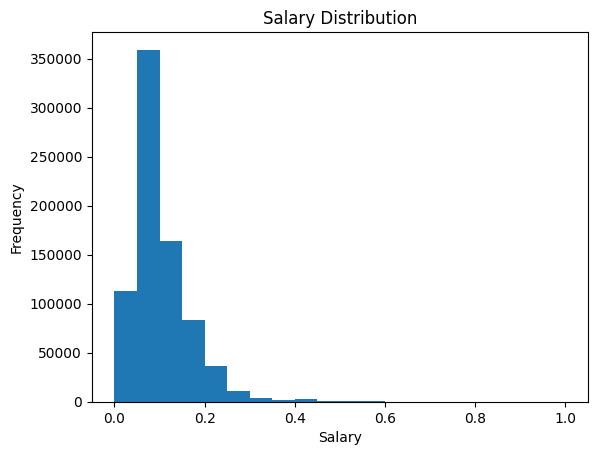

In [ ]:
plt.hist(df['Salary'], bins=20)
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.show()

<ipython-input-18-3ca46a0530d9>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['STATUS']  , color= 'green' )


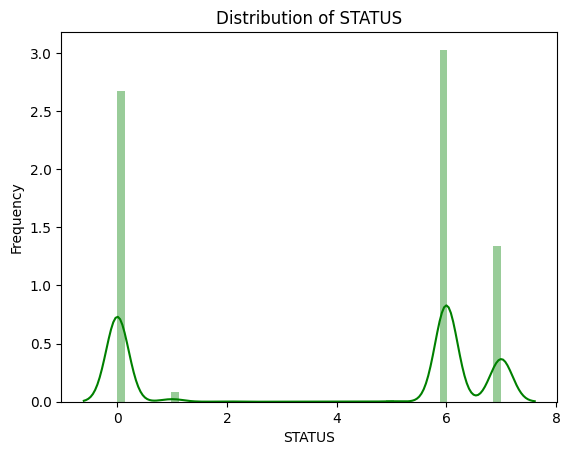

In [ ]:
sns.distplot(df['STATUS']  , color= 'green' )
plt.title("Distribution of STATUS")
plt.xlabel("STATUS")
plt.ylabel("Frequency")
plt.show()

###boxplot

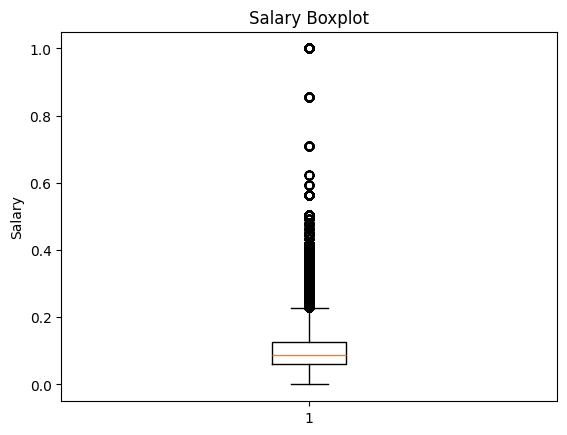

In [ ]:
plt.boxplot(df['Salary'])
plt.ylabel('Salary')
plt.title('Salary Boxplot')
plt.show()

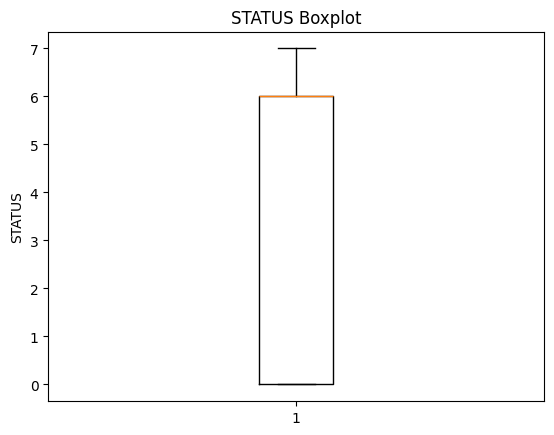

In [ ]:
plt.boxplot(df['STATUS'])
plt.ylabel('STATUS')
plt.title('STATUS Boxplot')
plt.show()

###Pie Chart

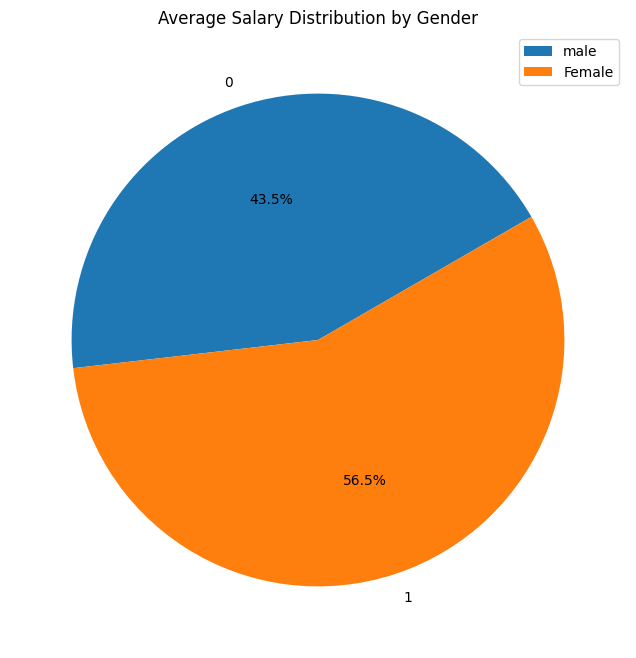

In [ ]:
salary_Gender=df.groupby("Gender")["Salary"].mean()
plt.figure(figsize=(8,8))
plt.pie(salary_Gender, labels=salary_Gender.index, autopct='%1.1f%%', startangle=30)
plt.title('Average Salary Distribution by Gender')
plt.legend(["male", "Female"])
plt.show()

###Heat map

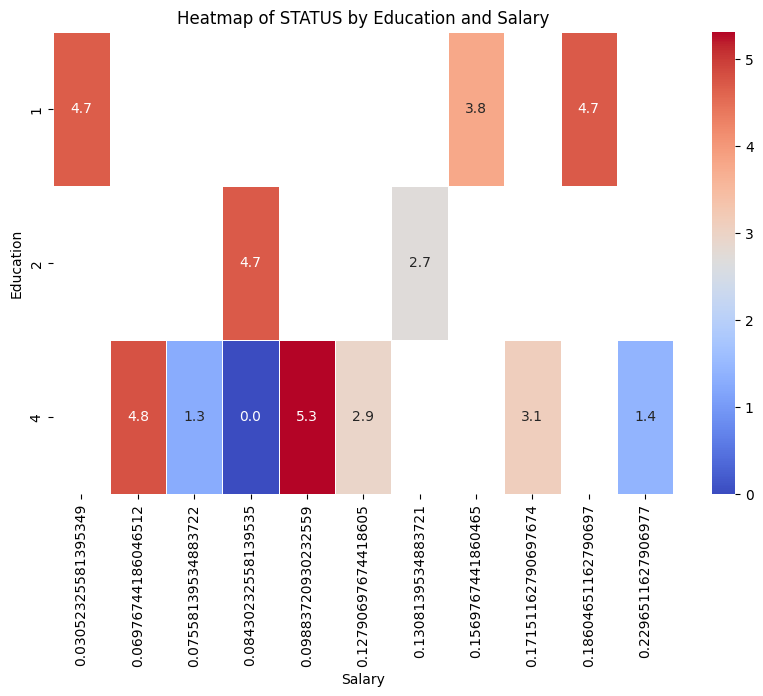

In [ ]:
samble_data = df.iloc[5000:7000][['STATUS', "Education", "Salary"]]
heatmap_data = samble_data.pivot_table(index='Education', columns='Salary', values='STATUS', aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,cmap='coolwarm', annot=True , fmt=".1f" , linewidths=.5)
plt.title("Heatmap of STATUS by Education and Salary")
plt.show()

#Decision Tree Model

In [ ]:
X = df.drop('STATUS', axis=1)
y = df['STATUS']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred = dt_classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.63      0.59     58003
           1       0.18      0.15      0.16      1743
           2       0.07      0.07      0.07       150
           3       0.04      0.04      0.04        52
           4       0.02      0.03      0.03        33
           5       0.51      0.44      0.47       307
           6       0.65      0.65      0.65     66226
           7       0.55      0.42      0.48     29029

    accuracy                           0.59    155543
   macro avg       0.32      0.30      0.31    155543
weighted avg       0.59      0.59      0.59    155543

[[36673   646    35    10     9    47 15118  5465]
 [  881   261    25     4     0     1   417   154]
 [   55    21    10     6     2     0    45    11]
 [   16     5     9     2     4     2     9     5]
 [    8     1     2     5     1     3    12     1]
 [   85     5     4     1    10   136    51    15]
 [18919   368    30    14    12    53 42727

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5910262756922523


#Logistics Regression

In [ ]:
df_sample = df.iloc[5000:20000]

In [ ]:
X = df_sample.drop('STATUS', axis=1)
y = df_sample['STATUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
logreg_classifier = LogisticRegression(max_iter=1000)
logreg_classifier.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = logreg_classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.51      0.49      1170
           1       0.00      0.00      0.00        20
           5       0.00      0.00      0.00         4
           6       0.50      0.65      0.57      1238
           7       0.31      0.04      0.08       568

    accuracy                           0.48      3000
   macro avg       0.25      0.24      0.23      3000
weighted avg       0.45      0.48      0.44      3000

[[602   0   0 530  38]
 [  6   0   0  12   2]
 [  4   0   0   0   0]
 [415   0   0 808  15]
 [279   0   0 264  25]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.47833333333333333


#SVM

In [ ]:
df_sample2 = df.iloc[5000:10000]

In [ ]:
X = df_sample2.drop('STATUS', axis=1)
y = df_sample2['STATUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.72      0.62       442
           1       0.00      0.00      0.00        10
           6       0.64      0.62      0.63       421
           7       0.00      0.00      0.00       127

    accuracy                           0.58      1000
   macro avg       0.29      0.34      0.31      1000
weighted avg       0.51      0.58      0.54      1000

[[319   0 123   0]
 [  7   0   3   0]
 [160   0 261   0]
 [103   0  24   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.58
